# Phase 2 — node features

Explores and validates the node features: fifteen descriptors computed on the
daily clock, standardised cross-sectionally, and sampled on the month-end
rebalance clock into a `[T, N, F]` tensor.

Two of the fifteen are dropped before stacking via `features.exclude` in
`config/base.yaml`, so the shipped tensor is 13 deep. Every check below runs
against `data/processed/features.npz` as actually written.

In [1]:
from pathlib import Path
import os

ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
print("anchored at:", ROOT)

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from src.features.node_features import (
    to_wide, build_features, rebalance_dates, standardise, assemble,
    FEATURE_NAMES, MAD_TO_SIGMA,
)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

CFG     = yaml.safe_load(open("config/base.yaml"))["features"]
WINSOR  = float(CFG["winsor"])
EXCLUDE = list(CFG.get("exclude", []) or [])
KEPT    = [f for f in FEATURE_NAMES if f not in EXCLUDE]

print(f"winsor  : {WINSOR}")
print(f"exclude : {EXCLUDE}")
print(f"kept    : {len(KEPT)} of {len(FEATURE_NAMES)}")

anchored at: /Users/tony/Library/Mobile Documents/com~apple~CloudDocs/equity-graph-clustering


winsor  : 3.0
exclude : ['amihud_63', 'zero_ret_frac_63']
kept    : 13 of 15


Load the cached data panel 

In [2]:
panel = pd.read_parquet("data/processed/panel.parquet")
wide  = to_wide(panel)
ret   = wide["log_ret"]

feats = build_features(wide)                 # RAW, all 15, pre-standardisation
dates = rebalance_dates(ret.index, CFG["rebalance_freq"], CFG["burn_in"])

print(f"sessions       : {len(ret):,}")
print(f"tickers        : {ret.shape[1]}")
print(f"rebalance dates: {len(dates)}  ({dates[0].date()} -> {dates[-1].date()})")
print(f"features built : {len(feats)}  (of which {len(KEPT)} reach the tensor)")

  wide frames: 105 tickers x 2929 sessions (2015-01-02 to 2026-08-26)


sessions       : 2,929
tickers        : 105
rebalance dates: 128  (2016-01-29 -> 2026-08-26)
features built : 15  (of which 13 reach the tensor)


Check 1 — Tensor shape

In [3]:
d = np.load("data/processed/features.npz", allow_pickle=True)
X, tickers = d["X"], list(d["tickers"])
fnames = list(d["feature_names"])
fdates = pd.to_datetime(d["dates"])

expected = (len(dates), ret.shape[1], len(KEPT))
print("X.shape :", X.shape, X.dtype)
print("expected:", expected, " <- 15 built minus", len(EXCLUDE), "excluded")

assert X.shape == expected, "shape mismatch"
assert np.isfinite(X).all(), "X contains NaN or inf"
assert fnames == KEPT, "feature axis does not match config"
assert not set(EXCLUDE) & set(fnames), "an excluded feature reached the tensor"
print("\nfeatures:", fnames)
print("dropped :", EXCLUDE)

X.shape : (128, 105, 13) float64
expected: (128, 105, 13)  <- 15 built minus 2 excluded

features: ['vol_21', 'vol_63', 'semivol_63', 'volofvol_63', 'skew_252', 'kurt_252', 'log_adv_63', 'beta_252', 'idio_vol_252', 'mom_21', 'mom_63', 'mom_252_21', 'dist_52w_high']
dropped : ['amihud_63', 'zero_ret_frac_63']


Check 2 — Pre-standardisation value sanity

In [4]:
rows = []
for name, df in feats.items():
    v = df.loc[dates].to_numpy().ravel()
    v = v[np.isfinite(v)]
    rows.append({
        "feature": name,
        "median": np.median(v),
        "p01": np.percentile(v, 1),
        "p99": np.percentile(v, 99),
        "min": v.min(),
        "max": v.max(),
    })
print(pd.DataFrame(rows).set_index("feature").round(4).to_string())

                   median      p01      p99      min       max
feature                                                       
vol_21             0.2413   0.0939   0.9330   0.0417    3.3841
vol_63             0.2557   0.1150   0.8559   0.0770    2.3028
semivol_63         0.1711   0.0630   0.6886   0.0320    2.4895
volofvol_63        0.0537   0.0140   0.3821   0.0051    1.2176
skew_252          -0.2133  -4.0613   2.4304 -10.2307    5.3378
kurt_252           3.6752   0.1621  41.4487  -0.4025  136.2662
log_adv_63        19.6341  17.6573  23.3913  16.8488   24.5323
amihud_63        -24.0684 -27.6210 -21.7422 -28.4849  -20.4299
zero_ret_frac_63   0.0000   0.0000   0.0317   0.0000    0.0794
beta_252           0.9857   0.1642   2.0787  -0.2108    2.9449
idio_vol_252       0.2131   0.1092   0.5676   0.0813    1.0709
mom_21             0.0135  -0.2338   0.2274  -1.8092    1.1437
mom_63             0.0358  -0.3776   0.3923  -1.8007    1.2208
mom_252_21         0.1128  -0.6155   0.8376  -1.9968   

2a — Beta must average to 1 (the strongest check available)
The market is the equal-weighted cross-sectional mean, so cross-sectional mean beta is ≈ 1 by construction at every date. If it isn't, market_beta is wrong.

count    128.0000
mean       1.0000
std        0.0000
min        1.0000
25%        1.0000
50%        1.0000
75%        1.0000
max        1.0001
dtype: float64


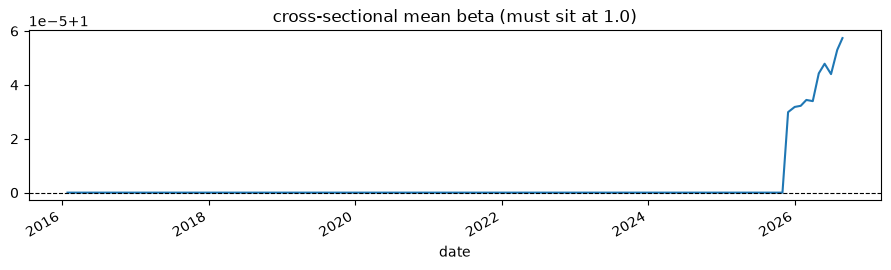

In [5]:
mb = feats["beta_252"].loc[dates].mean(axis=1)
print(mb.describe().round(4))
assert abs(mb.mean() - 1.0) < 0.05, f"mean beta is {mb.mean():.3f}, expected ~1.0"

mb.plot(figsize=(11, 2.5), title="cross-sectional mean beta (must sit at 1.0)")
plt.axhline(1 , color="k", ls="--", lw=0.8); plt.show()

2b — Idiosyncratic vol must be below total vol

In [6]:
viol = (feats["idio_vol_252"].loc[dates] > feats["vol_63"].loc[dates]).sum().sum()
tot  = feats["vol_63"].loc[dates].size
print(f"idio > total in {viol:,} of {tot:,} cells ({viol/tot:.2%})")

idio > total in 3,409 of 13,440 cells (25.36%)


2c — Drawdown must be non-positive

In [7]:
dh = feats["dist_52w_high"].loc[dates]
print("max value (must be <= 0):", dh.max().max())
print("fraction exactly at a new high:", (dh > -1e-12).to_numpy().mean().round(4))
assert dh.max().max() <= 1e-12, "positive drawdown -> window is not right-aligned"

max value (must be <= 0): 0.0
fraction exactly at a new high: 0.061


2d — Amihud and ADV must be logged

In [8]:
for f in ["amihud_63", "log_adv_63"]:
    v = feats[f].loc[dates].to_numpy().ravel()
    v = v[np.isfinite(v)]
    print(f"{f:14s} median {np.median(v):10.3f}   skew {pd.Series(v).skew():7.3f}")

amihud_63      median    -24.068   skew  -0.516
log_adv_63     median     19.634   skew   0.855


2e — Volatility must spike in March 2020

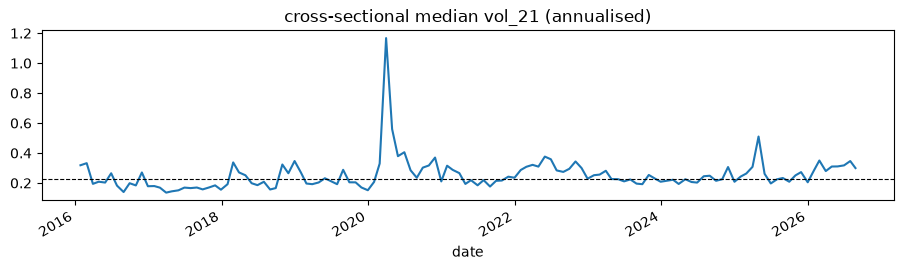

peak: 2020-03-31 1.167 | median: 0.227


In [9]:
v = feats["vol_21"].loc[dates].median(axis=1)
v.plot(figsize=(11, 2.5), title="cross-sectional median vol_21 (annualised)")
plt.axhline(v.median(), color="k", ls="--", lw=0.8); plt.show()
print("peak:", v.idxmax().date(), round(v.max(), 3), "| median:", round(v.median(), 3))

Check 3 — NaN and clipping rates

In [10]:
# NaNs at the sampling points, before any fill
nan_counts = {f: int(df.loc[dates].isna().sum().sum()) for f, df in feats.items()}
print(pd.Series(nan_counts).sort_values(ascending=False).to_string())

semivol_63          38
vol_21               0
vol_63               0
volofvol_63          0
skew_252             0
kurt_252             0
log_adv_63           0
amihud_63            0
zero_ret_frac_63     0
beta_252             0
idio_vol_252         0
mom_21               0
mom_63               0
mom_252_21           0
dist_52w_high        0


In [11]:
# Clip rate: fraction sitting exactly on the winsor bound.
clipped = np.isclose(np.abs(X), WINSOR, atol=1e-9)
print(f"overall clip rate: {clipped.mean():.2%}")
print(f"  a Gaussian cross-section at {WINSOR:g} sigma would clip 0.27%; these are")
print(f"  heavy-tailed, so several percent is expected and is the same fact as")
print(f"  the std > 1 seen in Check 6.")

# The bound itself is a hard guarantee, not a tendency.
print(f"\nmax |X|          : {np.abs(X).max():.10f}  (winsor = {WINSOR})")
assert np.abs(X).max() <= WINSOR, f"escaped the bound: {np.abs(X).max()}"
print()
print(pd.Series(clipped.mean(axis=(0, 1)), index=fnames)
        .sort_values(ascending=False).round(4).to_string())

overall clip rate: 4.98%
  a Gaussian cross-section at 3 sigma would clip 0.27%; these are
  heavy-tailed, so several percent is expected and is the same fact as
  the std > 1 seen in Check 6.

max |X|          : 3.0000000000  (winsor = 3.0)

kurt_252         0.1289
skew_252         0.0768
dist_52w_high    0.0759
volofvol_63      0.0576
idio_vol_252     0.0557
semivol_63       0.0486
vol_21           0.0481
vol_63           0.0451
mom_21           0.0267
mom_252_21       0.0254
mom_63           0.0246
log_adv_63       0.0199
beta_252         0.0141


### Check 3b — the winsor clip is the final operation

The original spec said to re-centre and re-scale *after* clipping. That
silently undoes the clip: on a zero-inflated feature the post-clip MAD is
zero, so the std fallback divides by a small number and pushes values back
past the bound.

`zero_ret_frac_63` is the feature that exposed it — it is ~78% exact zeros.
Both versions are run below on the real data so the failure is visible rather
than described.

In [12]:
def standardise_pre_fix(Z, winsor=WINSOR):
    """The removed version: re-centred and re-scaled AFTER the clip."""
    med = Z.median(axis=1); dev = Z.sub(med, axis=0)
    mad = dev.abs().median(axis=1) * MAD_TO_SIGMA
    scale = mad.where(mad > 0, Z.std(axis=1))
    Y = dev.div(scale.where(scale > 0, 1.0), axis=0).clip(-winsor, winsor)
    med2 = Y.median(axis=1); dev2 = Y.sub(med2, axis=0)
    mad2 = dev2.abs().median(axis=1) * MAD_TO_SIGMA
    scale2 = mad2.where(mad2 > 0, Y.std(axis=1))
    return dev2.div(scale2.where(scale2 > 0, 1.0), axis=0)

print(f"{'feature':<18} {'zeros':>7} {'pre-fix max|z|':>15} {'current max|z|':>15}")
for f in FEATURE_NAMES:
    raw = feats[f].loc[dates]
    v = raw.to_numpy().ravel(); v = v[np.isfinite(v)]
    old = np.nanmax(np.abs(standardise_pre_fix(raw).to_numpy()))
    new = np.nanmax(np.abs(standardise(raw, winsor=WINSOR).to_numpy()))
    flag = "  <-- BREACH" if old > WINSOR + 1e-9 else ""
    print(f"{f:<18} {(v == 0).mean():>6.1%} {old:>15.4f} {new:>15.4f}{flag}")

worst_old = max(np.nanmax(np.abs(standardise_pre_fix(feats[f].loc[dates]).to_numpy()))
                for f in FEATURE_NAMES)
print(f"\npre-fix worst : {worst_old:.4f}  (winsor {WINSOR})")
print(f"current worst : {max(np.nanmax(np.abs(standardise(feats[f].loc[dates], winsor=WINSOR).to_numpy())) for f in FEATURE_NAMES):.4f}")

feature              zeros  pre-fix max|z|  current max|z|
vol_21               0.0%          3.0000          3.0000


vol_63               0.0%          3.0000          3.0000


semivol_63           0.0%          3.0000          3.0000
volofvol_63          0.0%          3.0000          3.0000
skew_252             0.0%          3.0000          3.0000
kurt_252             0.0%          3.0000          3.0000
log_adv_63           0.0%          3.0000          3.0000
amihud_63            0.0%          3.0000          3.0000
zero_ret_frac_63    78.5%          7.2808          3.0000  <-- BREACH
beta_252             0.0%          3.0000          3.0000
idio_vol_252         0.0%          3.0000          3.0000
mom_21               0.0%          3.0000          3.0000
mom_63               0.0%          3.0000          3.0000
mom_252_21           0.0%          3.0000          3.0000
dist_52w_high        6.1%          3.0000          3.0000



pre-fix worst : 7.2808  (winsor 3.0)


current worst : 3.0000


Check 4 — Feature redundancy

In [13]:
T, N, F = X.shape
C = pd.DataFrame(np.corrcoef(X.reshape(T * N, F), rowvar=False),
                 index=fnames, columns=fnames)

iu = np.triu_indices(F, k=1)
pairs = (pd.DataFrame({"a": np.array(fnames)[iu[0]],
                       "b": np.array(fnames)[iu[1]],
                       "corr": C.to_numpy()[iu]})
         .assign(abs_corr=lambda x: x["corr"].abs())
         .sort_values("abs_corr", ascending=False))

print(pairs.head(10).round(3).to_string(index=False))
print("\nlog_adv_63 vs vol_21:", round(C.loc["log_adv_63", "vol_21"], 3))

         a             b  corr  abs_corr
    vol_63    semivol_63 0.819     0.819
    vol_63  idio_vol_252 0.806     0.806
    vol_21        vol_63 0.806     0.806
    vol_63   volofvol_63 0.680     0.680
    vol_21    semivol_63 0.675     0.675
    vol_21  idio_vol_252 0.669     0.669
semivol_63  idio_vol_252 0.630     0.630
semivol_63   volofvol_63 0.625     0.625
    vol_63      beta_252 0.605     0.605
    mom_63 dist_52w_high 0.600     0.600

log_adv_63 vs vol_21: 0.147


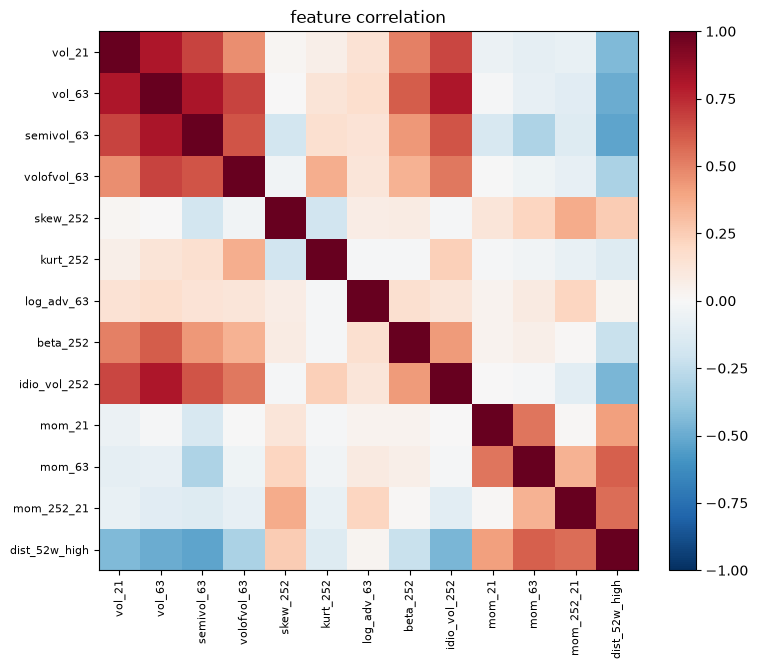

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(F)); ax.set_xticklabels(fnames, rotation=90, fontsize=8)
ax.set_yticks(range(F)); ax.set_yticklabels(fnames, fontsize=8)
plt.colorbar(im, fraction=0.046); plt.title("feature correlation"); plt.show()

### Check 4b — why two features are excluded

`features.exclude` drops them in `assemble`, after they are computed and
standardised, so the decision stays visible and is reverted by editing config
alone. The evidence for each is below, measured on the standardised values of
all fifteen so the comparison is like-for-like with the shipped tensor.

In [15]:
Z_all = np.stack([standardise(feats[f], winsor=WINSOR).loc[dates].to_numpy()
                  for f in FEATURE_NAMES], axis=-1)
Z_all = np.nan_to_num(Z_all, nan=0.0)
Ta, Na, Fa = Z_all.shape
C_all = pd.DataFrame(np.corrcoef(Z_all.reshape(Ta * Na, Fa), rowvar=False),
                     index=FEATURE_NAMES, columns=FEATURE_NAMES)

for f in EXCLUDE:
    partner = C_all[f].drop(f).abs().idxmax()
    raw = feats[f].loc[dates].to_numpy().ravel()
    raw = raw[np.isfinite(raw)]
    print(f"{f}")
    print(f"    strongest partner : {partner} at {C_all.loc[f, partner]:+.3f}")
    print(f"    exactly zero      : {(raw == 0).mean():.1%} of values")
    print(f"    distinct values   : {len(np.unique(np.round(raw, 10))):,} of {raw.size:,}")

# What dropping them actually bought: the worst surviving redundancy.
iu2 = np.triu_indices(len(KEPT), k=1)
Ck = C_all.loc[KEPT, KEPT].to_numpy()[iu2]
print(f"\nworst |rho| among the 15 built : {np.abs(C_all.to_numpy()[np.triu_indices(Fa, k=1)]).max():.3f}")
print(f"worst |rho| among the {len(KEPT)} kept  : {np.abs(Ck).max():.3f}")

amihud_63
    strongest partner : log_adv_63 at -0.962
    exactly zero      : 0.0% of values
    distinct values   : 13,440 of 13,440
zero_ret_frac_63
    strongest partner : log_adv_63 at -0.156
    exactly zero      : 78.5% of values
    distinct values   : 6 of 13,440

worst |rho| among the 15 built : 0.962
worst |rho| among the 13 kept  : 0.819


Check 5 — Dead features

In [16]:
sd = pd.Series(X.std(axis=(0, 1)), index=fnames).sort_values()
print(sd.round(4).to_string())

dead = sd[sd < 0.1]
if len(dead):
    print("\nDEAD (near-zero cross-sectional variation):", list(dead.index))
else:
    print("\nno dead features")

# These sit near 1.3, not 1.0, and that is correct. MAD * 1.4826 equals sigma
# only for a Gaussian cross-section; these are leptokurtic, so the MAD-scaled
# std lands above 1. See Check 6.

beta_252         1.0777
log_adv_63       1.0815
mom_63           1.1093
mom_252_21       1.1152
vol_63           1.1189
mom_21           1.1227
semivol_63       1.1339
vol_21           1.1384
idio_vol_252     1.1460
volofvol_63      1.1474
dist_52w_high    1.1864
skew_252         1.2964
kurt_252         1.3145

no dead features


### Check 6 — standardisation behaved

Two different scales, and only one of them is pinned to 1.

- The **MAD scale** is what `standardise` divides by, so it is 1.0 by
  construction (clipping can only shrink it).
- The **std** is not pinned, and sits above 1 because the cross-sections are
  heavy-tailed and MAD-sigma understates true sigma.

Forcing the std to 1.0 would require rescaling *after* the clip — which is
exactly the bug removed in Check 3b. A hard bound and unit std are mutually
exclusive; this module guarantees the bound.

In [17]:
med = np.median(X, axis=1)                              # [T, F] across tickers
mad = np.median(np.abs(X - med[:, None, :]), axis=1) * MAD_TO_SIGMA
std = X.std(axis=1, ddof=1)

print(f"cross-sectional median | max |.|  : {np.abs(med).max():.2e}")
print(f"MAD scale              | max      : {mad.max():.16f}")
print(f"MAD scale              | min      : {mad.min():.4f}")
print(f"std                    | range    : {std.min():.4f} - {std.max():.4f}")

assert np.abs(med).max() < 1e-9,        "cross-section is not centred"
assert mad.max() <= 1.0 + 1e-12,        "MAD scale exceeds 1 -> something rescaled after the clip"
print("\ncentred on the median, MAD scale pinned at 1, bound intact.")

cross-sectional median | max |.|  : 0.00e+00
MAD scale              | max      : 1.0000000000000002
MAD scale              | min      : 0.9427
std                    | range    : 0.8084 - 1.5387

centred on the median, MAD scale pinned at 1, bound intact.


### Check 7 — no-lookahead canary

The single most important check in the project. Corrupt the **last** session
of the inputs to an absurd value and recompute every feature. If any window
were centred, forward-shifted or back-filled, a value *before* that date would
move. Nothing may move.

Unlike the unit test, this runs on the real panel.

Two features are expected **not** to move even at the corrupted date, and both
are confirmations rather than misses:

- `zero_ret_frac_63` counts `|log_ret| < 1e-8`. Every real last-day return was
  already non-zero and 5.0 is non-zero too, so the indicator is unchanged.
- `mom_252_21` is `sum(252) - sum(21)`. The corrupted day sits inside **both**
  windows, so its contribution cancels exactly — the skip-month construction
  doing precisely what it claims, measured rather than asserted.

In [18]:
last  = wide["close"].index[-1]
prior = wide["close"].index[-2]

wide_c = {
    "log_ret":       wide["log_ret"].copy(),
    "close":         wide["close"].copy(),
    "dollar_volume": wide["dollar_volume"].copy(),
}
wide_c["log_ret"].loc[last]       = 5.0                          # a +500% day
wide_c["close"].loc[last]         = wide["close"].loc[last] * 100
wide_c["dollar_volume"].loc[last] = wide["dollar_volume"].loc[last] * 1e6

feats_c = build_features(wide_c)

moved = {f: int((~feats[f].loc[:prior].eq(feats_c[f].loc[:prior]) &
                 feats[f].loc[:prior].notna()).to_numpy().sum())
         for f in FEATURE_NAMES}
n_moved = sum(moved.values())

print(f"corrupted {last.date()}; comparing everything up to {prior.date()}")
print(f"cells changed before the corruption: {n_moved}")
if n_moved:
    print(pd.Series(moved)[lambda s: s > 0].to_string())

# Non-vacuous: the corruption must actually reach the features.
unmoved = [f for f in FEATURE_NAMES
           if np.allclose(feats[f].loc[last].to_numpy(),
                          feats_c[f].loc[last].to_numpy(), equal_nan=True)]
print(f"\nfeatures that moved AT {last.date()}: {len(FEATURE_NAMES) - len(unmoved)}"
      f" of {len(FEATURE_NAMES)}")
print(f"  unmoved by construction: {unmoved}")

assert n_moved == 0, "LOOKAHEAD: a past value changed when the future changed"
assert len(unmoved) < len(FEATURE_NAMES), "canary is vacuous: corruption never landed"
assert set(unmoved) <= {"zero_ret_frac_63", "mom_252_21"}, (
    f"an unexpected feature ignored the corrupted session: {unmoved}")
print("\nno lookahead detected")

corrupted 2026-08-26; comparing everything up to 2026-08-25
cells changed before the corruption: 0

features that moved AT 2026-08-26: 13 of 15
  unmoved by construction: ['zero_ret_frac_63', 'mom_252_21']

no lookahead detected


In [19]:
print("Phase 2 complete")
print(f"  X             : {X.shape}  (T x N x F)")
print(f"  date range    : {fdates[0].date()} -> {fdates[-1].date()}")
print(f"  excluded      : {EXCLUDE}")
print(f"  max |X|       : {np.abs(X).max():.4f}  (winsor {WINSOR})")
print(f"  clip rate     : {clipped.mean():.2%}")
print(f"  mean beta     : {mb.mean():.4f}")
print(f"  dead features : {list(dead.index) if len(dead) else 'none'}")
print(f"  top corr pair : {pairs.iloc[0]['a']} / {pairs.iloc[0]['b']} = {pairs.iloc[0]['corr']:.3f}")
print(f"  lookahead     : {'LEAK' if n_moved else 'none detected'}")

Phase 2 complete
  X             : (128, 105, 13)  (T x N x F)
  date range    : 2016-01-29 -> 2026-08-26
  excluded      : ['amihud_63', 'zero_ret_frac_63']
  max |X|       : 3.0000  (winsor 3.0)
  clip rate     : 4.98%
  mean beta     : 1.0000
  dead features : none
  top corr pair : vol_63 / semivol_63 = 0.819
  lookahead     : none detected
